<div>

<h1 align="center"> INF1007 - Session 2026H </h1>
<h2 align="center"> TP4 - Analyse de données sur les jeux Steam avec des librairies scientifiques</h2>
<br>

</div>


<b>
Travail realisé par : <br>
<br></b>
Cédric Gagnon <br>
Sedjro Tchegnon Orden Zannou <br>
<br>
<b>
Numéro de groupe de laboratoire :
<br><br>
</b>
L03-2
<br>


In [145]:
# Installations des librairies nécessaires pour le TP.
# Vous avez seulement besoin d'executer cette cellule une seule fois, lors de la première utilisation du Jupyter Notebook.
# Vous pouvez ensuite mettre les installations en commentaire pour éviter de les réexecuter à chaque fois que vous exécutez le Notebook au complet (avec "Run All").

%pip install pandas
%pip install matplotlib
%pip install seaborn
%pip install plotly
%pip install numpy


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


<h1><font color='lightblue'> Partie 1 - Chargement d'une base de données avec Pandas </font></h1>


<div class="alert alert-block alert-info" style="font-size:16px;">
Pour cette première partie du TP, nous utiliserons la librairie Pandas. Pour importer la librairie dans le Jupyter Notebook, vous pouvez exécuter la cellule suivante.
</div>


In [146]:
import pandas as pd
import numpy as np

<div class="alert alert-block alert-info" style="font-size:16px;">
<b>
1.1 Vous devez compléter la fonction "charger_donnees", qui permet de charger le contenu d'un fichier `.csv` en un DataFrame Pandas.
</b>
<br><br>
Un DataFrame Pandas est une structure de données tabulaires à deux dimensions, similaire à une feuille de calcul Excel. Il est composé de lignes et de colonnes, où :
<br><br>

- Chaque colonne représente une variable (ou un attribut) et a un nom.
<br>

- Chaque ligne représente une entrée (ou un enregistrement).
<br>

- Les indices (index) permettent d'identifier les lignes.
<br>
</div>


In [147]:
# TODO Compléter la fonction charger_donnees
def charger_donnees(file_path):
    '''
    Lire le fichier csv en paramètre et retourner un DataFrame contenant les données du fichier csv.
    @param file_path: le chemin vers le fichier csv (str)
    @return: DataFrame contenant les données du fichier csv.
    '''
    # TODO : Écrire votre code ici --> remplacer None

    
    with open(file_path) as csv_file:
        df = pd.read_csv(csv_file)  
      
    # Fin du code
    return df


<div class="alert alert-block alert-info" style="font-size:16px;">
<b>
1.2 Utilisez la fonction charger_donnees que vous venez de compléter pour charger le contenu du fichier steam_games_dataset.csv dans un DataFrame pandas.
</b>
</div>


In [148]:
# TODO Charger le fichier csv de données
df_steam = charger_donnees(r"C:\Users\cedri\OneDrive - polymtl\Cours\INF1007\tp4-l03-02\steam_games_dataset.csv")

<div class="alert alert-block alert-info" style="font-size:16px;">
<b>
1.3 Affichez les 5 premières lignes du DataFrame pour vérifier le chargement.
</b>
<br>
</div>


In [149]:
# TODO Afficher les 5 premières lignes du DataFrame
print(df_steam.head())


     appid                              name         developer  \
0      730  Counter-Strike: Global Offensive             Valve   
1  1172470                      Apex Legends           Respawn   
2   578080               PUBG: BATTLEGROUNDS  PUBG Corporation   
3  1623730                          Palworld        Pocketpair   
4      440                   Team Fortress 2             Valve   

         publisher  score_rank  positive  negative  userscore  \
0            Valve         NaN   7642084   1173003          0   
1  Electronic Arts         NaN    668053    326926          0   
2    KRAFTON, Inc.         NaN   1520457   1037487          0   
3       Pocketpair         NaN    358266     22443          0   
4            Valve         NaN   1044264    117208          0   

                       owners  average_forever  average_2weeks  \
0  100,000,000 .. 200,000,000            33852             708   
1  100,000,000 .. 200,000,000            10506             496   
2  100,000,000

<div class="alert alert-block alert-info" style="font-size:16px;">
<b>
1.4 Complétez la fonction supprimer_colonnes qui permet de supprimer une ou des colonnes d'un DataFrame.
</b>
<br>
</div>


In [150]:
# TODO Creer une fonction pour supprimer une ou des colonnes.
def supprimer_colonnes(dataframe, colonnes):
    '''
    Supprime les colonnes non pertinentes.

    @param dataframe : Le DataFrame a nettoyer.
    @param colonnes : Liste ou nom(s) de colonnes a supprimer.
    @return : Le DataFrame avec les colonnes supprimees
    '''
    # TODO Ecrire votre code ici

    if type(colonnes) == str:
        dataframe.pop(colonnes)
    else:
        for c in colonnes:
            dataframe.pop(c)
        
    return dataframe


<div class="alert alert-block alert-info" style="font-size:16px;">
<b>
1.5 Dans le cadre de votre analyse, vous constatez que la colonne "score_rank" est presque vide et que la colonne "userscore" contient très peu d'information exploitable pour les traitements demandés. Utilisez donc la fonction supprimer_colonnes que vous avez complété pour supprimer les colonnes "score_rank" et "userscore" de votre DataFrame.
</b>
<br>
</div>


In [151]:
# TODO Supprimer les colonnes "score_rank" et "userscore" de votre DataFrame. Remplacez None.

df_steam_clean = supprimer_colonnes(df_steam, ["score_rank", "userscore"])


<div class="alert alert-block alert-info" style="font-size:16px;">
<b>
1.6 Vérifiez que vos données sont uniformes et que vos colonnes sont bien supprimées en affichant les 15 premières lignes du DataFrame.
</b>
<br>
</div>


In [152]:
# TODO Afficher les 15 premières lignes du DataFrame
print(df_steam_clean.head(15))

      appid                              name  \
0       730  Counter-Strike: Global Offensive   
1   1172470                      Apex Legends   
2    578080               PUBG: BATTLEGROUNDS   
3   1623730                          Palworld   
4       440                   Team Fortress 2   
5   1938090   Call of Duty: Modern Warfare II   
6   1063730               New World: Aeternum   
7   2358720                Black Myth: Wukong   
8    271590         Grand Theft Auto V Legacy   
9       550                     Left 4 Dead 2   
10   304930                          Unturned   
11  1599340                          Lost Ark   
12   236390                       War Thunder   
13  2246340              Monster Hunter Wilds   
14   553850                      HELLDIVERS 2   

                                            developer  \
0                                               Valve   
1                                             Respawn   
2                                    PUBG Co

<div class="alert alert-block alert-info" style="font-size:16px;">
<b>
1.7 Après vérification, vous remarquez que la colonne "owners" contient des intervalles textuels comme "100,000 .. 200,000". Ce format complique les comparaisons numériques et les traitements statistiques.
<br><br>
Pour faciliter les analyses, complétez la fonction convertir_owners_min qui remplace le contenu de la colonne "owners" par la borne inferieure de l'intervalle, convertie en entier.
</b>
</div>


In [153]:
# TODO Créer une fonction pour convertir la colonne 'owners' en borne minimale numérique
def convertir_owners_min(dataframe):
    '''
    Remplace la colonne 'owners' par la borne inferieure de chaque intervalle,
    convertie en entier.

    @param dataframe : Le DataFrame a corriger.
    @return : Le DataFrame avec la colonne 'owners' transformee.
    '''
    i = 0
    for col in dataframe["owners"]:
        dataframe.loc[i, "owners"] = col.split("..")[0]
        i += 1
    return dataframe

convertir_owners_min(df_steam_clean)

,appid,name,developer,publisher,positive,negative,owners,average_forever,average_2weeks,median_forever,median_2weeks,price,initialprice,discount,ccu
0,730,Counter-Strike: Global Offensive,Valve,Valve,7642084,1173003,"100,000,000",33852,708,6645,301,0,0,0,1013936
1,1172470,Apex Legends,Respawn,Electronic Arts,668053,326926,"100,000,000",10506,496,935,246,0,0,0,124262
2,578080,PUBG: BATTLEGROUNDS,PUBG Corporation,"KRAFTON, Inc.",1520457,1037487,"100,000,000",23165,717,5622,261,0,0,0,314682
3,1623730,Palworld,Pocketpair,Pocketpair,358266,22443,"50,000,000",3854,835,2213,257,2999,2999,0,18028
4,440,Team Fortress 2,Valve,Valve,1044264,117208,"50,000,000",21244,736,4262,102,0,0,0,43819
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,444720,Inexistence,Jonathan BRASSAUD,Jonathan BRASSAUD,242,126,"50,000",279,0,313,0,299,299,0,0
9996,649600,Swords and Sandals 2 Redux,Whiskeybarrel Studios,eGames.com,429,117,"50,000",333,0,432,0,999,999,0,4
9997,1122120,STATIONflow,DMM GAMES,DMM GAMES,414,66,"50,000",984,0,984,0,1799,1799,0,6
9998,424640,Karaski: What Goes Up...,Unbound Creations,Unbound Creations,51,8,"50,000",0,0,0,0,1199,1199,0,0


<div class="alert alert-block alert-info" style="font-size:16px;">
<b>
1.8 Utilisez la fonction convertir_owners_min() pour transformer la colonne "owners".
</b>
<br>
</div>


In [154]:
# TODO Transformer la colonne 'owners'.
df_steam_clean = convertir_owners_min(df_steam_clean)


<div class="alert alert-block alert-info" style="font-size:16px;">
<b>
1.9 Pour faciliter les analyses, creez les colonnes suivantes :
<br><br>
- "Type_prix" : "Gratuit" si price vaut 0, sinon "Payant"
<br>
- "Etat_rabais" : "En rabais" si discount est superieur a 0, sinon "Prix regulier"
<br>
- "prix_dollars" : prix converti en dollars a partir de la colonne "price"
<br><br>
Utilisez np.where pour creer les deux premieres colonnes, puis affichez les 15 premieres lignes des colonnes pertinentes afin de verifier le resultat.
</b>
</div>


In [155]:
# TODO Créer les colonnes 'Type_prix', 'Etat_rabais' et 'prix_dollars'
# TODO Afficher les 15 premieres lignes des colonnes pertinentes
df_steam_clean["Type_prix"] = None
df_steam_clean["Etat_rabais"] = None
df_steam_clean["prix_dollars"] = None

for i in range(len(df_steam_clean)):
    df_steam_clean.loc[i, "Type_prix"] = "Gratuit" if df_steam_clean.loc[i, "price"] == 0 else "Payant"
    df_steam_clean.loc[i, "Etat_rabais"] = "En rabais" if df_steam_clean.loc[i, "discount"] != 0 else "Prix regulier"

    int_prix = int(df_steam_clean.loc[i, "price"] )
    if int_prix > 0:
        int_prix /= 100   

    df_steam_clean.loc[i, "prix_dollars"] = f"{int_prix}$"

print(df_steam_clean.head(15))

      appid                              name  \
0       730  Counter-Strike: Global Offensive   
1   1172470                      Apex Legends   
2    578080               PUBG: BATTLEGROUNDS   
3   1623730                          Palworld   
4       440                   Team Fortress 2   
5   1938090   Call of Duty: Modern Warfare II   
6   1063730               New World: Aeternum   
7   2358720                Black Myth: Wukong   
8    271590         Grand Theft Auto V Legacy   
9       550                     Left 4 Dead 2   
10   304930                          Unturned   
11  1599340                          Lost Ark   
12   236390                       War Thunder   
13  2246340              Monster Hunter Wilds   
14   553850                      HELLDIVERS 2   

                                            developer  \
0                                               Valve   
1                                             Respawn   
2                                    PUBG Co

<h1><font color='lightgreen'> Partie 2 - Calcul des statistiques </font></h1>


<div class="alert alert-block alert-success" style="font-size:16px;">
<b>
Dans cette deuxieme partie du TP, vous allez manipuler les donnees du DataFrame que vous venez de nettoyer.
</b>
</div>


<div class="alert alert-block alert-success" style="font-size:16px;">
<b>
2.1 Affichez le nombre de jeux gratuits versus payants, ainsi que le nombre de jeux en rabais versus à prix regulier.
<br>
</b>
</div>


In [156]:
# Indice : Vous pouvez utiliser value_counts().
# Pour que l'affichage soit optimal, convertissez votre Series pandas en DataFrame
# et réinitialisez l'index pour transformer l'affichage de votre première colonne.

# TODO Afficher en une seule commande le nombre de jeux gratuits et payants.
print("Nombre de jeux par type de prix :")
gratuit_vs_payant = df_steam_clean["Type_prix"].value_counts()
print(gratuit_vs_payant)


# TODO Afficher la répartition des jeux selon l'état du rabais.
print("\nRepartition des jeux selon l'etat du rabais :")
rabais_vs_regulier = df_steam_clean["Etat_rabais"].value_counts()
print(rabais_vs_regulier)


Nombre de jeux par type de prix :
Type_prix
Payant     7935
Gratuit    2065
Name: count, dtype: int64

Repartition des jeux selon l'etat du rabais :
Etat_rabais
Prix regulier    8697
En rabais        1303
Name: count, dtype: int64


<div class="alert alert-block alert-success" style="font-size:16px;">
<b>
2.2 Complétez la fonction stats_par_groupe qui permet de calculer une ou des statistiques d'une colonne du DataFrame selon un groupe selectionné.
<br>
</b>
</div>


In [157]:
# TODO Complétez la fonction stats_par_groupe (Indice : les fonctions groupby() et agg() pourront vous être utiles).
def stats_par_groupe(df, colonne_groupe, colonne_valeur, fonctions):
    '''
    Cette fonction doit calculer des statistiques pour une colonne selon un groupe.

    @param df : DataFrame
    @param colonne_groupe : colonne pour le groupement (ex: 'Type_prix')
    @param colonne_valeur : colonne à analyser (ex: 'average_forever')
    @param fonctions : liste ou fonction à appliquer (ex: ['mean', 'std'])
    @return : DataFrame des statistiques
    '''
    # Remplacez le None par votre code.
    df_stats = pd.DataFrame(df.groupby(colonne_groupe)[colonne_valeur].agg(fonctions))


    # Ne modifiez pas le code ci-dessous, c'est pour l'affichage.
    df_stats_long = df_stats.stack().reset_index()
    df_stats_long.rename(
        columns={
            df_stats_long.columns[1]: "Statistique",
            df_stats_long.columns[2]: "Valeur",
        },
        inplace=True,
    )

    return df_stats_long


<div class="alert alert-block alert-success" style="font-size:16px;">
<b>
2.3 À l'aide de la fonction stats_par_groupe, affichez les statistiques demandées dans les cellules suivantes.
</b>
<br>
</div>


In [158]:
# TODO Affichez la moyenne et l'ecart-type du temps de jeu moyen (average_forever) en fonction du type de prix.
print(stats_par_groupe(df_steam_clean, "Type_prix", "average_forever",[np.mean, np.std] ))

  Type_prix Statistique       Valeur
0   Gratuit        mean  1371.980145
1   Gratuit         std  4733.422240
2    Payant        mean   933.050536
3    Payant         std  4035.701620


In [159]:
# TODO Affichez le prix minimum et maximum des jeux selon l'état du rabais.
print(stats_par_groupe(df_steam_clean, "Etat_rabais", "prix_dollars", [min, max]))

     Etat_rabais Statistique  Valeur
0      En rabais         min   0.27$
1      En rabais         max   9.99$
2  Prix regulier         min      0$
3  Prix regulier         max  99.99$


In [160]:
# TODO Affichez le nombre moyen de joueurs simultanés (ccu) selon le type de prix.
print(stats_par_groupe(df_steam_clean, "Type_prix", "ccu", np.mean))

  Type_prix Statistique       Valeur
0   Gratuit         ccu  1070.418886
1    Payant         ccu   432.610334


<div class="alert alert-block alert-success" style="font-size:16px;">
<b>
2.4 Complétez la fonction suivante pour déterminer la proportion de jeux bien notés selon le type de prix. Un jeu sera consideré comme bien noté si son ratio d'évaluations positives est supérieur ou égal a 80 %.
<br>
</b>
</div>


In [161]:
# TODO Calculer la proportion de jeux bien notés par type de prix
def proportion_jeux_bien_notes_par_type_prix(dataframe):
    '''
    Calcule la proportion (en %) de jeux bien notés pour chaque type de prix.

    @param dataframe : Le DataFrame contenant les colonnes 'positive', 'negative' et 'Type_prix'.
    @return : Un DataFrame avec la proportion en pourcentage par type de prix, arrondie à 2 décimales.
    '''

    # TODO Créez une nouvelle colonne "ratio_positif" dans le DataFrame de sorte que :
    # - Le ratio soit calculé à partir de : positive / (positive + negative) * 100
    # - Si un jeu n'a aucune évaluation, on lui associe une valeur de 0
    # Indice : np.where peut vous aider à éviter une division par zéro
     
    for i in range(len(dataframe)):
        if (dataframe.loc[i, "positive"] + dataframe.loc[i, "negative"]) == 0 or (dataframe.loc[i, "positive"] == None and dataframe.loc[i, "negative"] == None):
            dataframe.loc[i, "ratio_positif"] = 0

        else:
            dataframe.loc[i, "ratio_positif"] = round(dataframe.loc[i, "positive"] / (dataframe.loc[i, "positive"] + dataframe.loc[i, "negative"]) * 100, 2)
    
    # TODO Créez une nouvelle colonne "Bien_note_bin" dans le DataFrame de sorte que :
    # - Si le jeu est bien noté, on lui associe le chiffre 1
    # - Sinon, on lui associe le chiffre 0
    dataframe["Bien_note_bin"] = None  

    for i in range(len(dataframe)):
        if dataframe.loc[i, "ratio_positif"] > 50:
            dataframe.loc[i, "Bien_note_bin"] = 1
        else:
            dataframe.loc[i, "Bien_note_bin"] = 0

    # TODO Calculer la proportion moyenne de jeux bien notés pour chaque type de prix (en pourcentage avec 2 décimales)
    df_pourcentage = dataframe.groupby("Type_prix")["Bien_note_bin"].mean().mul(100).round(2)

    # Transformer en DataFrame avec Type_prix comme colonne
    df_result = df_pourcentage.reset_index()
    df_result.columns = ["Type_prix", "Jeux_bien_notes"]
    return df_result


<div class="alert alert-block alert-success" style="font-size:16px;">
<b>
2.5 Affichez le DataFrame contenant la proportion (en %) de jeux bien notés, regroupée par type de prix.
<br>
</b>
</div>


In [162]:
# TODO Affichez le DataFrame résultant de la fonction proportion_jeux_bien_notes_par_type_prix
dernier_df = proportion_jeux_bien_notes_par_type_prix(df_steam_clean)
print(dernier_df)

  Type_prix Jeux_bien_notes
0   Gratuit           91.82
1    Payant           94.01


<h1><font color='coral'> Partie 3 - Visualisation des données </font></h1>


<div class="alert alert-warning" style="font-size:16px;">
<b>
Pour les graphiques demandés dans cette section, vous aurez besoin des librairies suivantes. Assurez-vous d'exécuter la prochaine cellule.
</b>
</div>


In [167]:
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt

<div class="alert alert-warning" style="font-size:16px;">
<b>
3.1 Visualisez les 10 éditeurs et les 10 développeurs les plus présents dans le dataset.
<br><br>
Utilisez seaborn pour créer deux graphiques en barres horizontales.
<br><br>
Affichez deux graphiques côte à côte :
<br><br>
- Le graphique de gauche : les 10 éditeurs (publisher) ayant le plus grand nombre de jeux
<br>
- Le graphique de droite : les 10 développeurs (developer) ayant le plus grand nombre de jeux
<br><br>
N'oubliez pas de nettoyer localement les valeurs manquantes avec "Inconnu" et de retirer les espaces superflus avant de compter.
<br><br>
Ajoutez un titre clair à chaque graphique, des noms d'axes et ajustez la mise en page avec plt.tight_layout().
<br><br>
Indice : vous pouvez utiliser value_counts().head(10) puis reset_index().
</b>
</div>


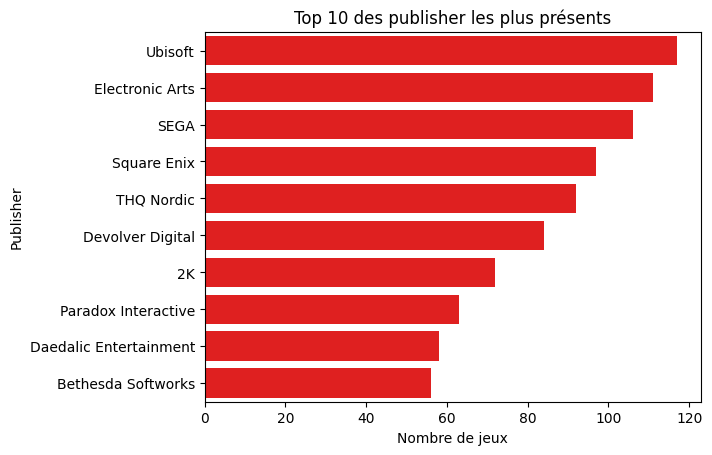

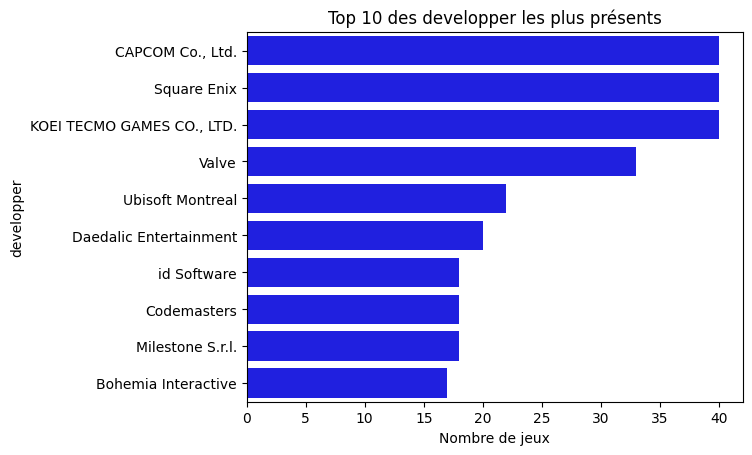

In [185]:
# TODO Tracer les deux graphiques en barres horizontales avec seaborn
df_best_publisher = df_steam_clean["publisher"].value_counts().head(10).reset_index()
df_best_developper = df_steam_clean["developer"].value_counts().head(10).reset_index()


sns.barplot(data=df_best_publisher, y='publisher', x='count', color="red")
plt.title("Top 10 des publisher les plus présents")
plt.xlabel("Nombre de jeux")
plt.ylabel("Publisher")
plt.show()
                            
sns.barplot(data=df_best_developper, y='developer', x='count', color="blue")
plt.title("Top 10 des developper les plus présents")
plt.xlabel("Nombre de jeux")
plt.ylabel("developper")
plt.show()


<div class="alert alert-warning" style="font-size:16px;">
<b>
3.2 Visualisez la relation entre les évaluations positives et négatives.
<br><br>
Utilisez Plotly Express pour créer un nuage de points (scatter plot) interactif.
<br><br>
- Sur l'axe X : positive
<br>
- Sur l'axe Y : negative
<br>
- Différenciez les points selon le type de prix (color='Type_prix')
<br>
- Faites varier la taille des points selon le nombre de joueurs simultanés (size='ccu')
<br>
- Creez des sous-graphiques (subplots) pour chaque état du rabais afin de comparer facilement les distributions
<br>
- Utilisez des axes logarithmiques pour mieux visualiser les jeux très populaires et les jeux plus modestes
<br>
- Pour mieux visualiser les petits points, ajoutez un contour gris à tous les points avec : 
fig.update_traces(marker=dict(line=dict(width=1, color='gray'), opacity=0.85))
<br><br>
Ajoutez un titre clair à la figure, centrez-le et affichez-la avec fig.show().
<br><br>
Indice : il est préferable de filtrer les jeux pour lesquels le nombre d'évaluations positives et negatives est strictement superieur à 0 avant de tracer le graphique.
</b>
</div>


In [200]:
# TODO Tracer le nuage de points interactif avec Plotly Express
positif_negatif = df_steam_clean[df_steam_clean["positive"] > 0]

fig = px.scatter(positif_negatif,
    x="positive",
    y="negative",
    color="Type_prix",
    size="ccu",
    title="Relation entre évaluations positives et négatives selon le prix et l'état du rabais",
    facet_col="Etat_rabais", 
    log_x=True,
    log_y=True
)
fig.update_traces(marker=dict (line=dict(width=1, color='gray')))




ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'hovertemplate': ('Type_prix=Gratuit<br>Etat_raba' ... '=%{marker.size}<extra></extra>'),
              'legendgroup': 'Gratuit',
              'marker': {'color': '#636efa',
                         'line': {'color': 'gray', 'width': 1},
                         'size': {'bdata': ('sHgPAGblAQA6zQQAK6sAAAsJAQCoKA' ... 'AAAAAAAAAAAAAAAAAAAAAAAAEAAAA='),
                                  'dtype': 'i4'},
                         'sizemode': 'area',
                         'sizeref': 2534.84,
                         'symbol': 'circle'},
              'mode': 'markers',
              'name': 'Gratuit',
              'showlegend': True,
              'type': 'scattergl',
              'x': {'bdata': ('5Jt0AJUxCgBJMxcAKO8PAMyMGgCUug' ... 'AA6gIAAGYBAABhBQAAIwAAANgBAAA='),
                    'dtype': 'i4'},
              'xaxis': 'x',
              'y': {'bdata': ('C+YRAA79BACv1A8A2MkBANDSAwDUvg' ... 'AArAAAADcAAABqAgAACgAAAGEAAAA='),
                    'dtype': 'i4'},
              'yaxis': 'y'},
             {'hovertemplate': ('Type_prix=Payant<br>Etat_rabai' ... '=%{marker.size}<extra></extra>'),
              'legendgroup': 'Payant',
              'marker': {'color': '#EF553B',
                         'line': {'color': 'gray', 'width': 1},
                         'size': {'bdata': ('bEYAAM8VAACcOgAAImIAAM4wAACX0A' ... 'AAAAAABAAAAAYAAAAAAAAABgAAAA=='),
                                  'dtype': 'i4'},
                         'sizemode': 'area',
                         'sizeref': 2534.84,
                         'symbol': 'circle'},
              'mode': 'markers',
              'name': 'Payant',
              'showlegend': True,
              'type': 'scattergl',
              'x': {'bdata': ('encFAL4AAwCo9hAAvVgOACnxAQDL1g' ... 'DyAAAArQEAAJ4BAAAzAAAA/wYAAA=='),
                    'dtype': 'i4'},
              'xaxis': 'x',
              'y': {'bdata': ('q1cAAOBfAQDqlQAA0lwAAAZkAQBYsA' ... 'B+AAAAdQAAAEIAAAAIAAAAYwEAAA=='),
                    'dtype': 'i4'},
              'yaxis': 'y'},
             {'hovertemplate': ('Type_prix=Payant<br>Etat_rabai' ... '=%{marker.size}<extra></extra>'),
              'legendgroup': 'Payant',
              'marker': {'color': '#EF553B',
                         'line': {'color': 'gray', 'width': 1},
                         'size': {'bdata': ('WwcBADBkAQB2agAAZyEAAGc4AAC2Aw' ... 'AAAAAAAAAYAAAAAAAAAAIAAAAPAAAA'),
                                  'dtype': 'i4'},
                         'sizemode': 'area',
                         'sizeref': 2534.84,
                         'symbol': 'circle'},
              'mode': 'markers',
              'name': 'Payant',
              'showlegend': False,
              'type': 'scattergl',
              'x': {'bdata': ('CmcGAGJhDQCXEQkABCoEAJsxBwANFg' ... 'AAAAcCAACjBAAAOQAAAIQAAABsBgAA'),
                    'dtype': 'i4'},
              'xaxis': 'x2',
              'y': {'bdata': ('eH4EAJhEAACTDAEALlcAANluAAB7LA' ... 'AAAHEAAAAdAgAAPAAAAHwAAAAxAgAA'),
                    'dtype': 'i4'},
              'yaxis': 'y2'}],
    'layout': {'annotations': [{'font': {},
                                'showarrow': False,
                                'text': 'Etat_rabais=Prix regulier',
                                'x': 0.245,
                                'xanchor': 'center',
                                'xref': 'paper',
                                'y': 1.0,
                                'yanchor': 'bottom',
                                'yref': 'paper'},
                               {'font': {},
                                'showarrow': False,
                                'text': 'Etat_rabais=En rabais',
                                'x': 0.755,
                                'xanchor': 'center',
                                'xref': 'paper',
                                'y': 1.0,
                                'yanchor': 'bottom',
                                'yref': 'paper'}],
             

<h1><font color='cornflowerblue'> Bonus (+1 point) - Affichage d'un graphique en barre superposé </font></h1>


<div class="alert alert-success" style="font-size:16px; color: darkblue; background-color: cornflowerblue;">
<b>
Pour obtenir 1 point bonus, vous pouvez utiliser la librairie matplotlib pour visualiser la répartition des jeux bien notés (80 % ou plus d'évaluations positives) versus les autres, selon le type de prix, au moyen d'un graphique en barre superposé.
</b>
</div>


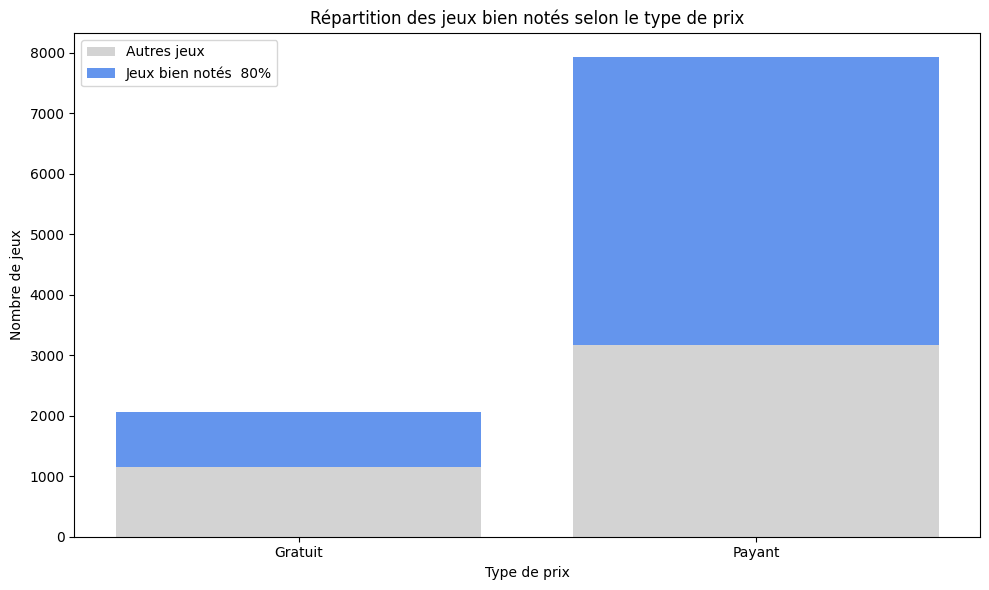

In [203]:
# TODO Ecrire votre code ici pour la question bonus
df_ratio_bien_reussi = df_steam_clean[df_steam_clean["ratio_positif"] >= 80]
df_autres = df_steam_clean[df_steam_clean["ratio_positif"] < 80]

counts_bien_reussi = df_ratio_bien_reussi["Type_prix"].value_counts()
counts_autres = df_autres["Type_prix"].value_counts()

tout = sorted(df_steam_clean["Type_prix"].unique())

counts_bien_reussi = counts_bien_reussi.reindex(tout, fill_value=0)
counts_autres = counts_autres.reindex(tout, fill_value=0)

plt.figure(figsize=(10, 6))

plt.bar(tout, counts_autres.values, label="Autres jeux", color="lightgray")
plt.bar(tout, counts_bien_reussi.values, bottom=counts_autres.values, label="Jeux bien notés  80%", color="cornflowerblue")

plt.title("Répartition des jeux bien notés selon le type de prix")
plt.xlabel("Type de prix")
plt.ylabel("Nombre de jeux")
plt.legend()
plt.tight_layout()
plt.show()
